In [1]:
%load_ext autoreload
%autoreload 2

# add code directory to path
import sys
import os
sys.path.append(os.path.join(os.path.abspath(''), 'code'))  

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
from config import load_config

In [15]:
config = load_config("configs/config_hammer.yaml", verbose=False)
sequences_df = pd.read_csv(config["dataset_path"])

In [16]:
from epinnet import (position_pair_epistasis, all_pairs_epinnet_analysis, base_mlp,
                     all_pairs_epistasis, extract_epistatic_pairs, print_summary)

In [5]:
from bootstrap import get_oh_table

In [6]:
oh_funclib_df, y, design_numbers = get_oh_table(
    config["dataset_path"],
    first_col=config["first_column_name"],
    last_col=config["last_column_name"],
    y_col="fold_improvement"
)
# oh_funclib_df = oh_funclib_df.iloc[1:]
# experimental_results_df = pd.read_csv(f"{config["data_dir_path"]}/experimental_results.csv")
# y = experimental_results_df["malathion"]
# shift y index such that it starts from 1
# y.index = range(1, len(y) + 1)
log_y = np.log(y + 1e-8)  # avoid log(0)

In [8]:
def pair_comparison(df, pos1, mut1, pos2, mut2):
    both_df = df[(df[pos1] == mut1) & (df[pos2] == mut2)]
    only1_df = df[(df[pos1] == mut1) & (df[pos2] != mut2)]
    only2_df = df[(df[pos1] != mut1) & (df[pos2] == mut2)]
    neither_df = df[(df[pos1] != mut1) & (df[pos2] != mut2)]

    both_mean = both_df["fold_improvement"].mean()
    only1_mean = only1_df["fold_improvement"].mean()
    only2_mean = only2_df["fold_improvement"].mean()
    neither_mean = neither_df["fold_improvement"].mean()

    # plot distribution of fold improvement for each group
    plt.figure(figsize=(10, 6))
    plt.hist(both_df["fold_improvement"], bins=20, alpha=0.5, label="Both")
    plt.hist(only1_df["fold_improvement"], bins=20, alpha=0.5, label=f"{pos1}={mut1} Only")
    plt.hist(only2_df["fold_improvement"], bins=20, alpha=0.5, label=f"{pos2}={mut2} Only")
    plt.hist(neither_df["fold_improvement"], bins=20, alpha=0.5, label="Neither")
    plt.axvline(both_mean, color='blue', linestyle='dashed', linewidth=1)
    plt.axvline(only1_mean, color='orange', linestyle='dashed', linewidth=1)
    plt.axvline(only2_mean, color='green', linestyle='dashed', linewidth=1)
    plt.axvline(neither_mean, color='red', linestyle='dashed', linewidth=1)
    plt.legend()
    plt.xlabel("Fold Improvement")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Fold Improvement for {pos1}={mut1} and {pos2}={mut2}")
    plt.show()

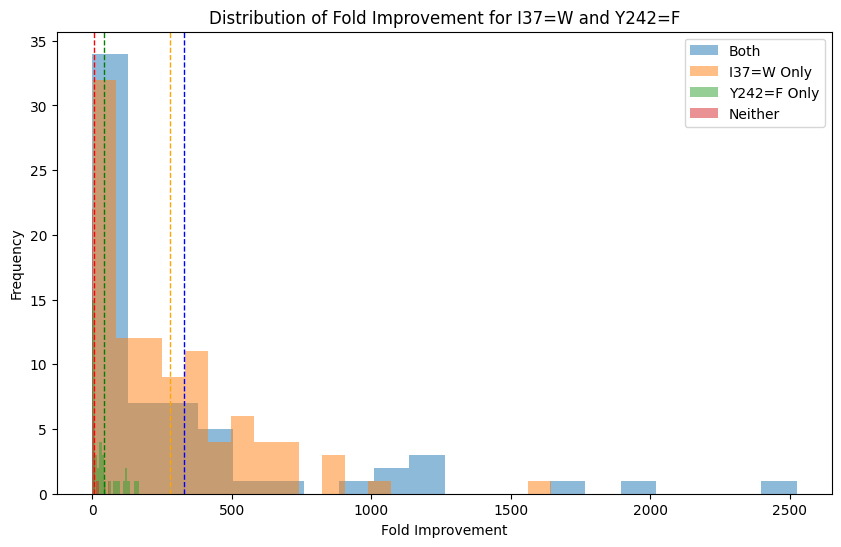

In [9]:
pair_comparison(sequences_df, "I37", "W", "Y242", "F")

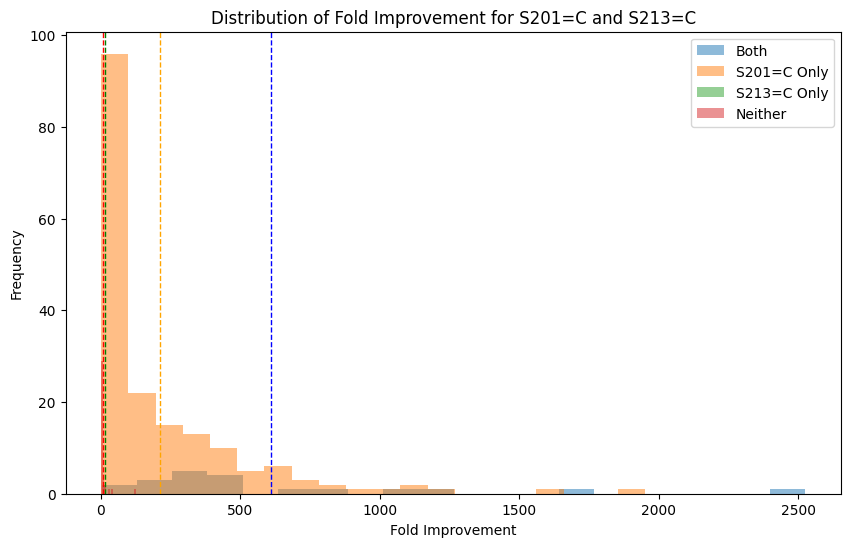

In [10]:
pair_comparison(sequences_df, "S201", "C", "S213", "C")

In [11]:
def pair_comparison_summary(df, pos1, mut1, pos2, mut2):
    both_df = df[(df[pos1] == mut1) & (df[pos2] == mut2)]
    only1_df = df[(df[pos1] == mut1) & (df[pos2] != mut2)]
    only2_df = df[(df[pos1] != mut1) & (df[pos2] == mut2)]
    neither_df = df[(df[pos1] != mut1) & (df[pos2] != mut2)]

    summary_df = pd.DataFrame({
        "group": ["both", f"{pos1}={mut1}", f"{pos2}={mut2}", "neither"],
        "mean": [both_df["fold_improvement"].mean(), only1_df["fold_improvement"].mean(), only2_df["fold_improvement"].mean(), neither_df["fold_improvement"].mean()],
        "std": [both_df["fold_improvement"].std(), only1_df["fold_improvement"].std(), only2_df["fold_improvement"].std(), neither_df["fold_improvement"].std()],
        "count": [len(both_df), len(only1_df), len(only2_df), len(neither_df)],
        "unique_identities_at_pair": [None, only1_df[pos2].nunique(), only2_df[pos1].nunique(), None]
    })
    
    return summary_df

In [12]:
pair_comparison_summary(sequences_df, "I37", "W", "Y242", "F")

,group,mean,std,count,unique_identities_at_pair
0,both,330.148438,507.800507,64,NaN
1,I37=W,279.212121,275.675577,99,5.0
2,Y242=F,41.657895,49.214932,38,5.0
3,neither,6.840541,12.621861,37,NaN


In [13]:
pair_comparison_summary(sequences_df, "S201", "C", "S213", "C")

,group,mean,std,count,unique_identities_at_pair
0,both,610.360000,612.937725,20,NaN
1,S201=C,212.696089,298.339212,179,8.0
2,S213=C,16.200000,NaN,1,1.0
3,neither,8.200000,21.484765,38,NaN


In [14]:
# do pair comparison for all pairs of positions and mutations
from itertools import combinations
pairs = list(combinations(oh_funclib_df.columns, 2))
pair_summaries = []
for col1, col2 in pairs:
    pos1, mut1 = col1.split("_")
    pos2, mut2 = col2.split("_")
    summary_df = pair_comparison_summary(sequences_df, pos1, mut1, pos2, mut2)
    # keep only if all counts are greater than 1
    if (summary_df["count"] > 1).all():
        pair_summaries.append((col1, col2, summary_df))

In [15]:
ratio_threshold = 3
inverse_ratio_threshold = 1 / ratio_threshold

In [16]:
# find pairs where both mean is greater than only1 and only2 means, and neither mean is the lowest
positively_epistatic_pairs = []
pos_sign_epistasis_pairs = []

for col1, col2, summary_df in pair_summaries:
    both_mean = summary_df[summary_df["group"] == "both"]["mean"].values[0]
    only1_mean = summary_df[summary_df["group"] == col1.replace("_", "=")]["mean"].values[0]
    only2_mean = summary_df[summary_df["group"] == col2.replace("_", "=")]["mean"].values[0]
    neither_mean = summary_df[summary_df["group"] == "neither"]["mean"].values[0]
    
    both_to_1_ratio = both_mean / only1_mean if only1_mean != 0 else np.inf
    both_to_2_ratio = both_mean / only2_mean if only2_mean != 0 else np.inf
    both_to_neither_ratio = both_mean / neither_mean if neither_mean != 0 else np.inf

    if both_to_neither_ratio >= ratio_threshold and only1_mean >= neither_mean and only2_mean >= neither_mean and both_mean >= only1_mean and both_mean >= only2_mean:
        positively_epistatic_pairs.append((col1, col2, summary_df))
    
    if (neither_mean > only1_mean and neither_mean > only2_mean) and (both_to_neither_ratio >= ratio_threshold):
        pos_sign_epistasis_pairs.append((col1, col2, summary_df))

In [17]:
positively_epistatic_pairs

[('Y20_Y',
  'D167_H',
       group        mean         std  count  unique_identities_at_pair
  0     both  242.932850  357.390487    207                        NaN
  1    Y20=Y    9.922222   14.794616     18                        3.0
  2   D167=H   14.655556   41.882458      9                        2.0
  3  neither    2.500000    2.772484      4                        NaN),
 ('Y20_Y',
  'Y242_F',
       group        mean         std  count  unique_identities_at_pair
  0     both  225.812000  429.488969    100                        NaN
  1    Y20=Y  223.076000  268.699917    125                        6.0
  2   Y242=F   65.650000   85.772053      2                        1.0
  3  neither    0.963636    1.653646     11                        NaN),
 ('Y20_Y',
  'N249_C',
       group        mean         std  count  unique_identities_at_pair
  0     both  274.379310  357.340757     29                        NaN
  1    Y20=Y  216.881122  347.562080    196                        5.0
  2 

In [18]:
pos_sign_epistasis_pairs

[('Y20_Y',
  'S201_C',
       group        mean         std  count  unique_identities_at_pair
  0     both  255.184264  362.118748    197                        NaN
  1    Y20=Y    6.942857    9.755091     28                        7.0
  2   S201=C    4.250000    0.777817      2                        1.0
  3  neither   12.127273   37.894250     11                        NaN),
 ('E34_E',
  'Y176_F',
       group        mean         std  count  unique_identities_at_pair
  0     both  322.560959  395.359501    146                        NaN
  1    E34=E   21.938182   63.324170     55                        2.0
  2   Y176=F   47.792857   76.795948     14                        4.0
  3  neither   71.217391  101.369749     23                        NaN),
 ('Y242_L',
  'F253_F',
       group         mean         std  count  unique_identities_at_pair
  0     both  1172.200000  668.074487      2                        NaN
  1   Y242=L   206.364286  215.585391     14                        1.0


In [19]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

def mutation_predictability(oh_df, mut, y):
    mut_df = oh_df[oh_df[mut] == 1]
    non_mut_df = oh_df[oh_df[mut] == 0]

    mlp_reg_oh = MLPRegressor(
            hidden_layer_sizes=(128),
            activation="relu",
            learning_rate="invscaling",
            solver="lbfgs",
            random_state=42,
            verbose=True,
            max_iter=20000,
    )
    mlp_reg_oh.fit(non_mut_df, y[non_mut_df.index])
    mut_pred = mlp_reg_oh.predict(mut_df)

    # compute loss
    mut_mse = mean_squared_error(y[mut_df.index], mut_pred)
    spearman_corr, _ = spearmanr(y[mut_df.index], mut_pred)

    return mut_mse, spearman_corr
    

In [20]:
mses, spearman_corrs, muts = [], [], []
for col in oh_funclib_df.columns:
    if col[0] == col[-1]: # Skip wt
        continue
    mut_mse, spearman_corr = mutation_predictability(oh_funclib_df, col, log_y)
    mses.append(mut_mse)
    muts.append(col)
    spearman_corrs.append(spearman_corr)

mses = np.array(mses)
spearman_corrs = np.array(spearman_corrs)
# replace nan values in spearman_corrs with 0
spearman_corrs = np.nan_to_num(spearman_corrs, nan=0.0)

/tmp/ipykernel_2311635/1650895635.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, _ = spearmanr(y[mut_df.index], mut_pred)


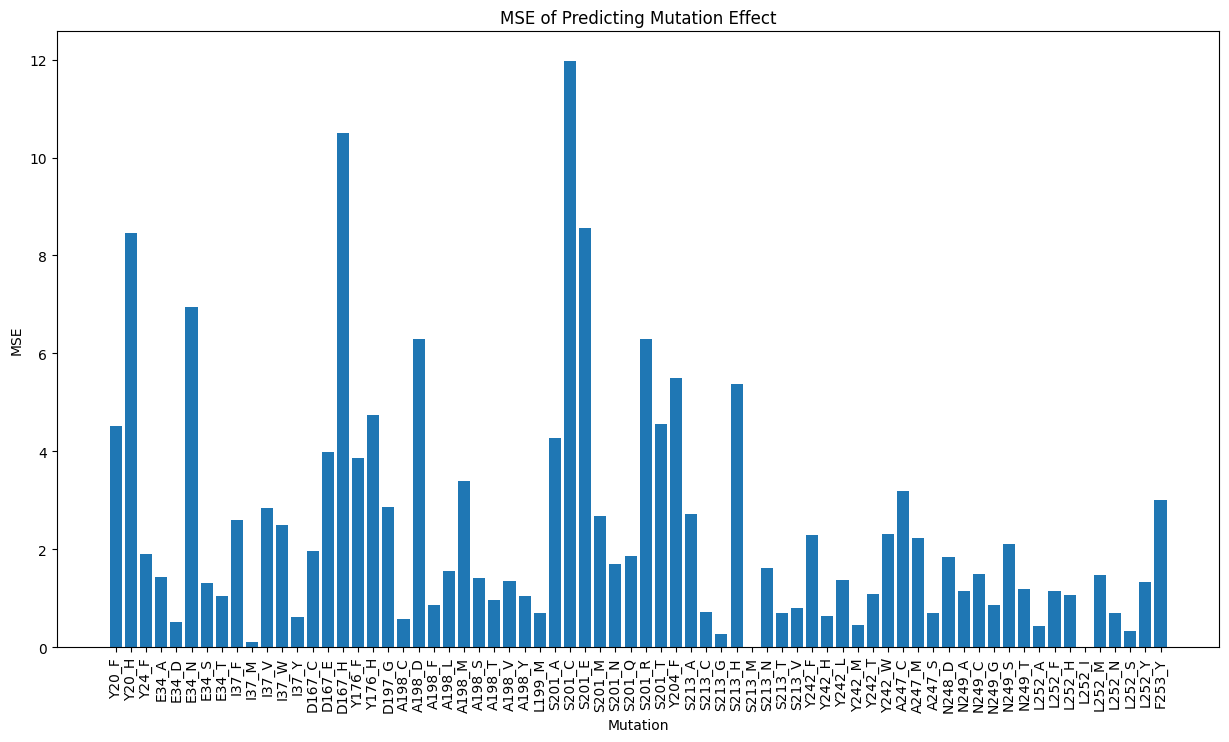

In [21]:
# bar plot mses
plt.figure(figsize=(15, 8))
plt.bar(muts, mses)
plt.xticks(rotation=90)
plt.xlabel("Mutation")
plt.ylabel("MSE")
plt.title("MSE of Predicting Mutation Effect")
plt.show()

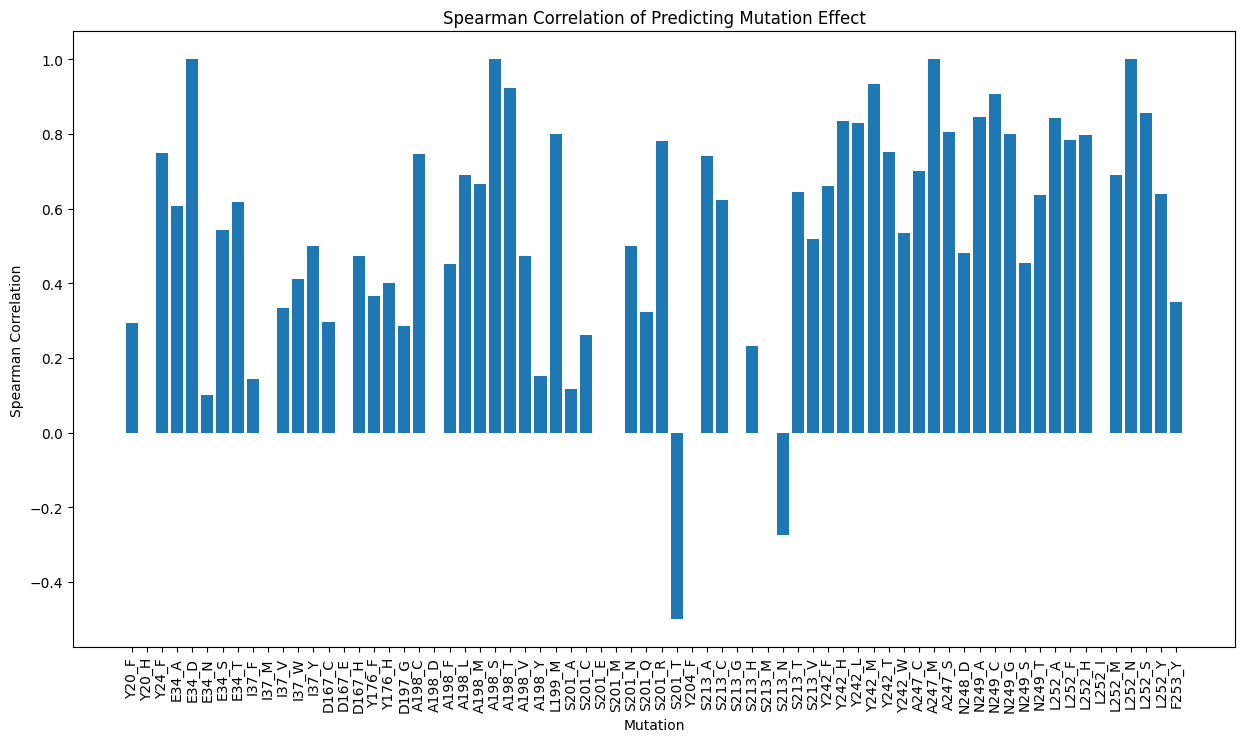

In [22]:
# plot spearman correlations
plt.figure(figsize=(15, 8))
plt.bar(muts, spearman_corrs)
plt.xticks(rotation=90)
plt.xlabel("Mutation")
plt.ylabel("Spearman Correlation")
plt.title("Spearman Correlation of Predicting Mutation Effect")
plt.show()

In [23]:
# aggregate per position by taking the mean of mses and spearman_corrs for mutations at the same position
positions = [col[:-2] for col in oh_funclib_df.columns]
position_mses = {}
position_spearman_corrs = {}
for pos in set(positions):
    pos_mses = [mses[i] for i, col in enumerate(oh_funclib_df.columns) if col.startswith(pos)]
    pos_spearman_corrs = [spearman_corrs[i] for i, col in enumerate(oh_funclib_df.columns) if col.startswith(pos)]
    position_mses[pos] = np.mean(pos_mses)
    position_spearman_corrs[pos] = np.mean(pos_spearman_corrs)

IndexError: index 70 is out of bounds for axis 0 with size 70

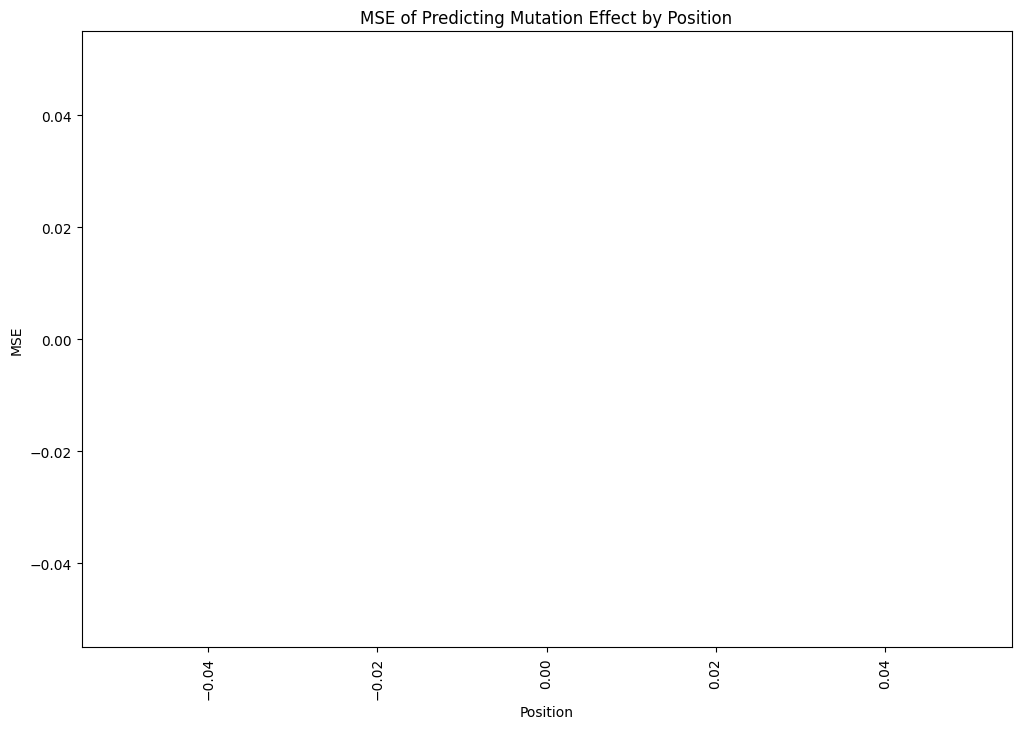

In [ ]:
# bar plot position mses
plt.figure(figsize=(12, 8))
plt.bar(position_mses.keys(), position_mses.values())
plt.xticks(rotation=90)
plt.xlabel("Position")
plt.ylabel("MSE")
plt.title("MSE of Predicting Mutation Effect by Position")
plt.show()

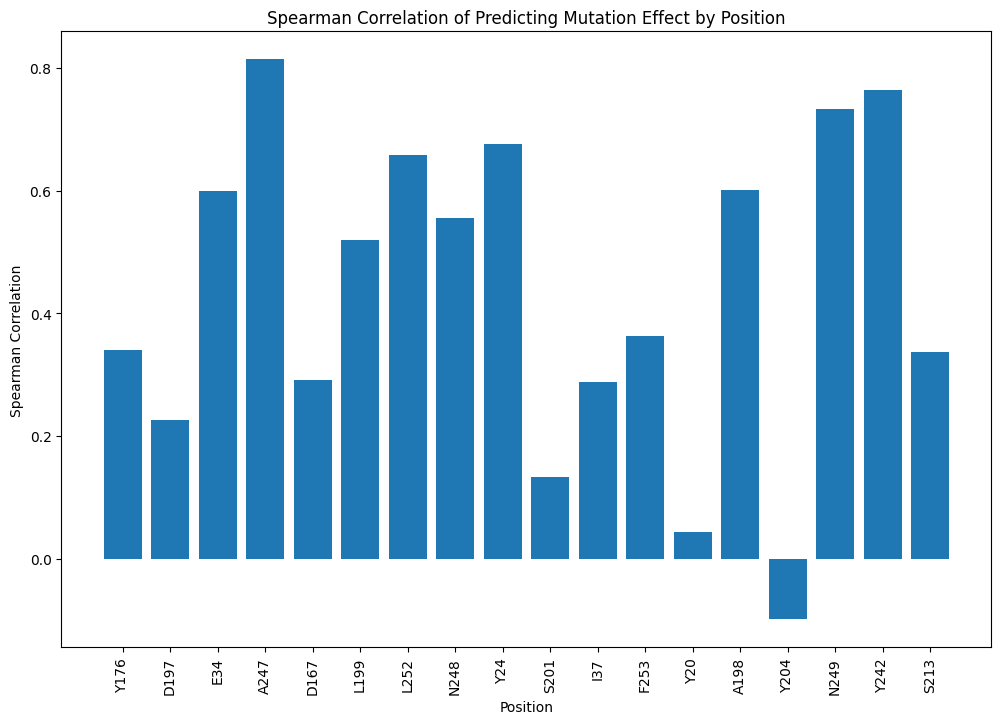

In [ ]:
# bar plot position spearman correlations
plt.figure(figsize=(12, 8))
plt.bar(position_spearman_corrs.keys(), position_spearman_corrs.values())
plt.xticks(rotation=90)
plt.xlabel("Position")
plt.ylabel("Spearman Correlation")
plt.title("Spearman Correlation of Predicting Mutation Effect by Position")
plt.show()

In [ ]:
# flag mutations with high mse and low spearman correlation
threshold_mse = np.percentile(mses, 75)
threshold_spearman = np.percentile(spearman_corrs, 25)
flagged_mutations = (mses > threshold_mse) & (spearman_corrs < threshold_spearman)
flagged_mutation_names = oh_funclib_df.columns[flagged_mutations]
print("Flagged Mutations with High MSE and Low Spearman Correlation:")
print(flagged_mutation_names)

Flagged Mutations with High MSE and Low Spearman Correlation:
Index(['Y20_H', 'Y20_Y', 'Y24_Y', 'E34_N', 'D197_D', 'A198_D', 'S201_E',
       'S201_S', 'S201_T', 'Y204_F', 'Y204_Y', 'S213_H'],
      dtype='object')


In [ ]:
oh_funclib_df.columns[mses > np.percentile(mses, 80)]

Index(['Y20_H', 'Y20_Y', 'Y24_Y', 'E34_N', 'I37_I', 'D167_D', 'D167_H',
       'D197_D', 'A198_D', 'L199_L', 'S201_C', 'S201_E', 'S201_R', 'Y204_F',
       'Y204_Y', 'S213_H', 'L252_L', 'F253_F'],
      dtype='object')

In [ ]:
oh_funclib_df.columns[spearman_corrs < np.percentile(spearman_corrs, 20)]

Index(['Y20_H', 'Y20_Y', 'Y24_Y', 'E34_N', 'I37_M', 'D167_E', 'A198_D',
       'S201_A', 'S201_E', 'S201_M', 'S201_S', 'S201_T', 'Y204_F', 'Y204_Y',
       'S213_G', 'S213_M', 'S213_N', 'L252_I'],
      dtype='object')

In [ ]:
# calculate variant predictability by multiplying the oh df and the mses
variant_predictability = oh_funclib_df.values @ spearman_corrs

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 70 is different from 88)

In [ ]:
variant_predictability

array([133.89345037, 123.17674663, 145.28638891, 137.33994381,
       133.45748697, 137.91307934, 143.07994927, 132.82279595,
       132.76060186, 124.34824121, 139.90978307, 134.55601569,
       113.56006082, 123.36046199, 125.91773337, 139.12040613,
       132.55946544, 122.90141988, 110.97436589, 126.04590372,
       122.77941886, 122.67378795, 138.14646044, 120.81679849,
       116.63692031, 121.30388058, 133.48870006, 126.27525396,
       140.88723953, 126.95550137, 124.99959388, 144.97166909,
       116.07242934, 135.06796332, 139.84645725, 122.53196648,
       117.79366915, 139.77749939, 114.00188217, 126.62320164,
       133.7423086 , 126.19105525, 130.4662415 , 128.33154413,
       135.19756954, 126.04193786, 124.78838764, 117.41108043,
       125.66773667, 137.06824958, 114.64745019, 126.43574789,
       129.11903645, 125.01453147, 125.14361063, 129.49747425,
       123.4536823 , 126.59464424, 123.8321201 , 128.87786233,
       125.17342782, 127.18079159, 122.44421927, 127.31